# MAna.analysis - Visual Exploration and Communication

`MAna.analysis` is the visualization and dashboard layer of MAna. It is not tied to one type of dataset; it is meant to help with regular analytics work: distributions, comparisons, trends, relationships, hierarchy, flows, funnels, financial bridges, animation, and dashboard starters.

This notebook uses multiple real datasets from old project work:

- `Womens Clothing E-Commerce Reviews.csv` for customer/review analytics.
- `YoutubeDataCleaned.csv` for time, popularity, and category examples.
- `tmdb_5000_movies.csv` for movie hierarchy, genre, revenue, and budget analysis.
- `electricityLoadData - Q3.csv` for clean animated time-pattern examples.

The important lesson is that visual analysis is usually two jobs: prepare the right table, then call the right chart.


## What this module covers

- Styling: `set_matplotlib_defaults`.
- Basic charts: `line`, `scatter`, `bar`, `area_plot`, `pie_plot`.
- Distribution and relationship charts: `dist`, `plot_box`, `heatmap`, `pairplot`, `violin`, `scatter_3d`.
- Hierarchy and flow charts: `sunburst`, `treemap`, `sankey`, `funnel_chart`, `waterfall_chart`.
- Animated charts: `animated_scatter`, `animated_line`.
- Dashboard starters: `create_dashboard_template`, `quick_dashboard`.

Some helpers display a figure and also return it. In notebooks, assign the result to a variable, or use `show=False` where available, to avoid displaying the same figure twice.

In [27]:
from ast import literal_eval
from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from MAna.analysis import (
    animated_line,
    animated_scatter,
    area_plot,
    bar,
    create_dashboard_template,
    dist,
    funnel_chart,
    heatmap,
    line,
    pairplot,
    pie_plot,
    plot_box,
    quick_dashboard,
    sankey,
    scatter,
    scatter_3d,
    set_matplotlib_defaults,
    sunburst,
    treemap,
    violin,
    waterfall_chart,
)
from MAna.data import DataCleaner, read_data

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

# During automated docs checks, there is no notebook frontend to receive Plotly
# output. Suppressing .show() there keeps the notebook executable as plain Python.
# In Jupyter, this flag stays True and charts display normally.
RUNNING_IN_NOTEBOOK = "get_ipython" in globals()
if not RUNNING_IN_NOTEBOOK:
    go.Figure.show = lambda *args, **kwargs: None


## 1. Load real analysis datasets

The analysis module should not be demonstrated with one dataset only. Different chart families need different data shapes, so we load three real samples and prepare each for a different analytics problem.

In [28]:
# Keep paths flexible so the notebook works from the repo root or docs/notebooks.
reviews_path = Path("data/womens_clothing_reviews_sample.csv")
youtube_path = Path("data/youtube_trending_sample.csv")
youtube_categories_path = Path("data/youtube_category_names.csv")
tmdb_path = Path("data/tmdb_5000_movies.csv")
electricity_path = Path("data/electricity_load_q3.csv")

if not reviews_path.exists():
    reviews_path = Path("docs/notebooks/data/womens_clothing_reviews_sample.csv")
    youtube_path = Path("docs/notebooks/data/youtube_trending_sample.csv")
    youtube_categories_path = Path("docs/notebooks/data/youtube_category_names.csv")
    tmdb_path = Path("docs/notebooks/data/tmdb_5000_movies.csv")
    electricity_path = Path("docs/notebooks/data/electricity_load_q3.csv")

# read_data() is the front door for file loading in MAna.data.
# Keep format-specific options here instead of scattering pandas calls later.
reviews = read_data(reviews_path)
youtube = read_data(youtube_path)
youtube_categories = read_data(youtube_categories_path)
tmdb = read_data(tmdb_path)
electricity_raw = read_data(electricity_path)

{
    "reviews": reviews.shape,
    "youtube": youtube.shape,
    "youtube_categories": youtube_categories.shape,
    "tmdb": tmdb.shape,
    "electricity": electricity_raw.shape,
}


{'reviews': (160, 11),
 'youtube': (20000, 15),
 'youtube_categories': (32, 2),
 'tmdb': (4803, 20),
 'electricity': (70128, 6)}

In [29]:
# MAna.data is useful before MAna.analysis: load, clean the obvious issues,
# and then build analysis tables with predictable columns.
reviews = (
    DataCleaner(reviews, verbose=False)
    .remove_duplicates()
    .fix_missing_values(strategy={"Age": "median", "Title": "mode", "Review Text": "mode", "Division Name": "mode", "Department Name": "mode", "Class Name": "mode"})
    .get_cleaned_data()
)

# Prepare the reviews table for distribution and relationship plots.
# These features are simple but useful: text length and readable recommendation labels.
reviews_analysis = DataCleaner(reviews, verbose=False).fix_missing_values(fill_value={"Review Text": ""}).get_cleaned_data()
reviews_analysis["Review Length"] = reviews_analysis["Review Text"].str.split().str.len()
reviews_analysis["Recommended Label"] = np.where(
    reviews_analysis["Recommended IND"].eq(1),
    "Recommended",
    "Not Recommended",
)

# YouTube already has analytics-friendly column names, but still benefits from
# the shared cleaner for duplicate removal and basic missing-value handling.
youtube = (
    DataCleaner(youtube, verbose=False)
    .remove_duplicates()
    .fix_missing_values(strategy={"description": "mode", "category_id": "mode"})
    .get_cleaned_data()
)

# Prepare the YouTube table for time and category plots.
# The source uses strings like 18-25-02, which means year-day-month.
youtube_analysis = (
    DataCleaner(youtube, verbose=False)
    .parse_dates(columns=["trending_date"], extract_features=False, date_format="%y-%d-%m")
    .get_cleaned_data()
)
youtube_categories_clean = (
    DataCleaner(youtube_categories, verbose=False)
    .standardize_column_names()
    .rename_columns({"id": "category_id"})
    .remove_duplicates(subset=["category_id"])
    .get_cleaned_data()
)
youtube_analysis = youtube_analysis.merge(
    youtube_categories_clean,
    on="category_id",
    how="left",
)
youtube_analysis = DataCleaner(youtube_analysis, verbose=False).fix_missing_values(fill_value={"category_name": "Unknown"}).get_cleaned_data()
youtube_analysis["engagement"] = (
    youtube_analysis["likes"] + youtube_analysis["comment_count"]
) / youtube_analysis["views"].replace(0, np.nan)

# Standardize electricity columns through DataCleaner so the animation prep reads cleanly.
electricity = (
    DataCleaner(electricity_raw, verbose=False)
    .standardize_column_names()
    .remove_duplicates()
    .fix_missing_values(strategy={"temperature": "median", "demand": "median"})
    .convert_data_types()
    .get_cleaned_data()
)
electricity["timestamp"] = pd.to_datetime(
    dict(year=electricity["year"], month=electricity["month"], day=electricity["day"]),
    errors="coerce",
) + pd.to_timedelta(electricity["hours"], unit="s")
electricity["hour"] = (electricity["hours"] // 3600).astype(int)
electricity["date"] = electricity["timestamp"].dt.date

# Prepare the movie table for hierarchy, financial, and genre analysis.
# TMDB stores genres as JSON-like strings. We convert them into Python lists.
def parse_names(value):
    try:
        parsed = literal_eval(value) if isinstance(value, str) else []
    except (ValueError, SyntaxError):
        parsed = []
    return [item.get("name") for item in parsed if isinstance(item, dict) and item.get("name")]

tmdb_analysis = DataCleaner(tmdb, verbose=False).parse_dates(columns=["release_date"], extract_features=False).get_cleaned_data()
tmdb_analysis["genre_list"] = tmdb_analysis["genres"].apply(parse_names)
tmdb_analysis["release_year"] = tmdb_analysis["release_date"].dt.year
tmdb_analysis["decade"] = (tmdb_analysis["release_year"] // 10 * 10).astype("Int64").astype(str) + "s"
tmdb_analysis["profit"] = tmdb_analysis["revenue"] - tmdb_analysis["budget"]
tmdb_analysis["profitability"] = np.select(
    [
        tmdb_analysis["budget"].eq(0) | tmdb_analysis["revenue"].eq(0),
        tmdb_analysis["profit"].gt(0),
    ],
    ["Missing budget/revenue", "Profitable"],
    default="Not profitable",
)

reviews_analysis.head(2), youtube_analysis.head(2), electricity.head(2), tmdb_analysis.head(2)


(   Unnamed: 0  Clothing ID  Age Title  \
 0           0          767   33  Huge   
 1           1         1080   34  Huge   
 
                                                                                  Review Text  \
 0                                      Absolutely wonderful - silky and sexy and comfortable   
 1  Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i ...   
 
    Rating  Recommended IND  Positive Feedback Count Division Name  \
 0       4                1                        0     Initmates   
 1       5                1                        4       General   
 
   Department Name Class Name  Review Length Recommended Label  
 0        Intimate  Intimates              8       Recommended  
 1         Dresses    Dresses             62       Recommended  ,
         CITY STATE COUNTRY trending_date  \
 0  Covington    KY     USA    2018-02-25   
 1  Covington    KY     USA    2018-02-26   
 
                                  

## 2. Styling defaults

`set_matplotlib_defaults()` is small but useful. It standardizes matplotlib and seaborn output early in the notebook, especially before heatmaps.

In [30]:
# These defaults affect matplotlib/seaborn figures, not Plotly figures.
# Keep this near the top of the notebook so later matplotlib charts inherit it.
set_matplotlib_defaults(cmap="viridis", titlesize=16, labelsize="medium")

## 3. Basic charts on real analytics questions

Start with the common questions: what is biggest, what changes over time, how are two signals related, and what share does each category own?

In [31]:
# bar(): category comparison.
# Use the reviews data because department volume is a clean categorical question.
department_summary = (
    reviews_analysis.dropna(subset=["Department Name"])
    .groupby("Department Name", as_index=False)
    .agg(
        reviews=("Rating", "size"),
        avg_rating=("Rating", "mean"),
        recommended_rate=("Recommended IND", "mean"),
        avg_review_length=("Review Length", "mean"),
    )
    .sort_values("reviews", ascending=False)
) # groups the reviews by department and calculates summary statistics for each department, including total number of reviews, average rating, recommendation rate, and average review length

bar(
    department_summary,
    x_col="Department Name",
    y_col="reviews",
    color_col="Department Name",
    title="Review Volume by Department",
    x_title="Department",
    y_title="Reviews",
    auto_open=False,
) # sets up a bar chart to visualize the number of reviews for each department, with appropriate titles and labels

In [32]:
# scatter(): relationship between two numeric variables.
# It returns a figure, so store it before custom edits to avoid duplicate display.
fig = scatter(
    reviews_analysis.dropna(subset=["Department Name"]),
    x_col="Review Length",
    y_col="Positive Feedback Count",
    color_col="Department Name",
    size_col="Rating",
    title="Review Length vs Positive Feedback",
    x_title="Review length in words",
    y_title="Positive feedback count",
    opacity=0.65,
    marker={"line": {"width": 0.5, "color": "black"}},
    auto_open=False,
) # creates a scatter plot to visualize the relationship between review length and positive feedback count, with points colored by department, sized by rating, and customized marker appearance
fig.update_layout(legend_title_text="Department")
fig.show()

In [33]:
# line(): time trend.
# YouTube is the right dataset here because it has a real trending date.
daily_youtube = (
    youtube_analysis.dropna(subset=["trending_date"])
    .groupby("trending_date", as_index=False)
    .agg(
        total_views=("views", "sum"),
        total_likes=("likes", "sum"),
        total_comments=("comment_count", "sum"),
        videos=("title", "count"),
    )
    .sort_values("trending_date")
) # groups the YouTube data by trending date and calculates summary statistics for each date, including total views, total likes, total comments, and the number of videos that trended on that date

line(
    daily_youtube,
    x_col="trending_date",
    y_col="total_views",
    title="Daily Trending YouTube Views",
    x_title="Trending date",
    y_title="Total views",
    color="darkslateblue",
) # creates a line plot to visualize the total number of views for trending YouTube videos over time, with appropriate titles and labels

In [34]:
# area_plot(): cumulative or volume-over-time stories.
# This is much stronger with the YouTube dataset than with the small reviews table.
daily_youtube["cumulative_views"] = daily_youtube["total_views"].cumsum()

area_plot(
    daily_youtube,
    x_col="trending_date",
    y_col="cumulative_views",
    title="Cumulative Views Across the Trending Window",
    x_title="Trending date",
    y_title="Cumulative views",
)

In [35]:
# pie_plot(): share of a whole.
# It writes HTML by default, so use a temporary file during experiments.
category_share = (
    youtube_analysis.groupby("category_name", as_index=False)
    .agg(videos=("title", "count"))
    .sort_values("videos", ascending=False)
    .head(10)
) # groups the YouTube data by category and calculates the number of videos in each category, then selects the top 10 categories by video count

with tempfile.TemporaryDirectory() as tmpdir:
    fig = pie_plot(
        category_share,
        values_column="videos",
        names_column="category_name",
        title="Top YouTube Categories by Trending Video Count",
        filename=str(Path(tmpdir) / "youtube_category_share.html"),
        auto_open=False,
    ) # creates a pie chart to visualize the share of trending YouTube videos by category, with appropriate titles and labels, and saves it as an HTML file in a temporary directory

fig.show()

## 4. Distributions and relationships

These plots are for spread, shape, outliers, correlations, and group differences. The reviews dataset is good for this because it has customer age, rating, feedback, text length, and recommendation labels.

In [36]:
# dist(): histogram with mean, median, and mode lines.
# The source now uses Scatter line traces, so it should not raise Plotly's deprecated go.Line warning.
dist(
    reviews_analysis,
    col="Age",
    lenght=2,
    title="Age Distribution in Clothing Reviews",
)

In [37]:
# heatmap(): numeric correlation matrix.
# Return value is the seaborn/matplotlib axis, so you can keep editing it.
numeric_review_cols = [
    "Age",
    "Rating",
    "Recommended IND",
    "Positive Feedback Count",
    "Review Length",
]
ax = heatmap(
    reviews_analysis[numeric_review_cols],
    figsize=(8, 6),
    cmap="Greens",
    annot_kws={"fontsize": 8},
)
ax.set_title("Correlation Between Review Signals")
plt.close(ax.figure)

In [38]:
# pairplot(): scatter-matrix for several numeric features.
# Use a focused set of columns; throwing every numeric column into a pair plot
# usually makes it unreadable. `size=20` means fixed marker size.
fig = pairplot(
    reviews_analysis[
        ["Age", "Rating", "Positive Feedback Count", "Review Length", "Recommended Label"]
    ],
    color="Recommended Label",
    size=1200,
    show=False,
)
fig.show()


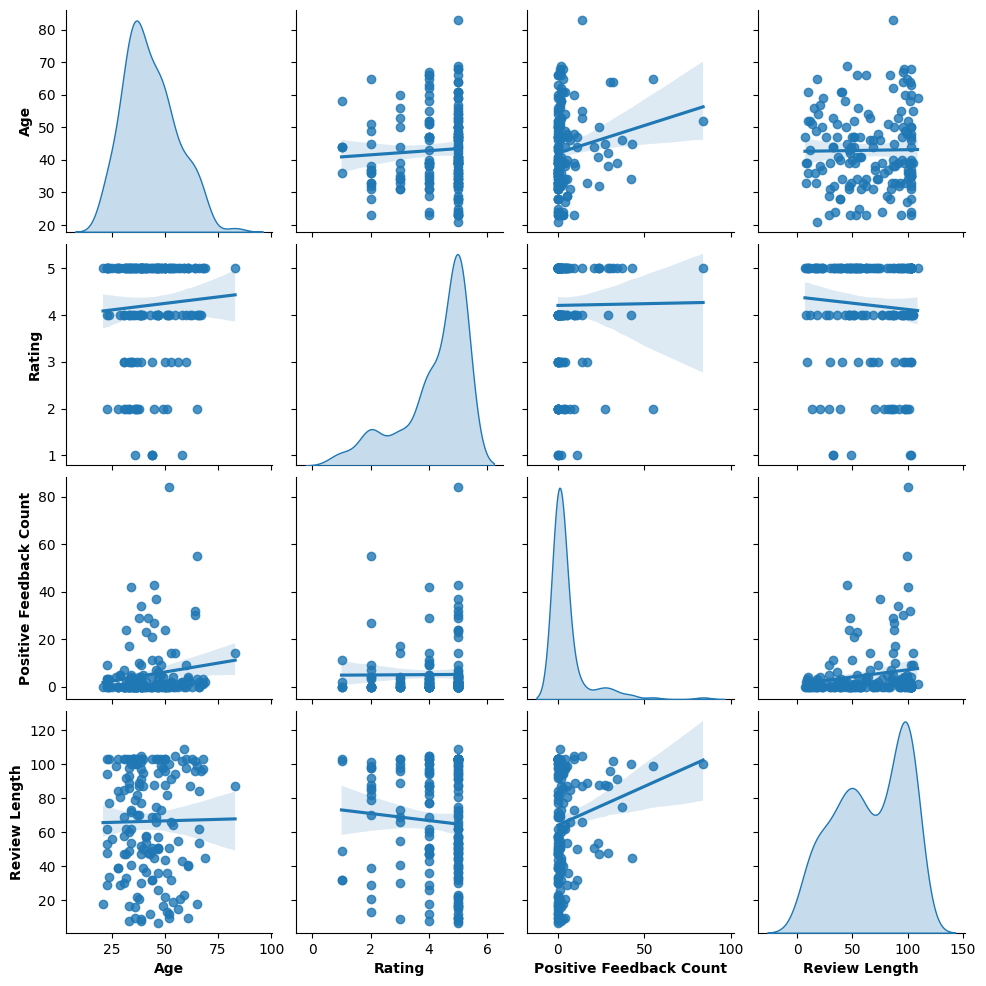

In [39]:
from MAna.analysis import pairplot_seaborn

fig = pairplot_seaborn(
    reviews_analysis[
        ["Age", "Rating", "Positive Feedback Count", "Review Length", "Recommended Label"]
    ],
    # hue="Recommended Label",
    kind="reg",
    diag_kind="kde",
    palette="Set2",
)

In [40]:
# violin(): compare distributions across groups.
# This shows whether customer age varies by department, including spread and skew.
fig = violin(
    reviews_analysis.dropna(subset=["Department Name"]),
    x_col="Department Name",
    y_col="Age",
    color_col="Department Name",
    title="Age Distribution by Department",
    show=False,
)
fig.show()

In [41]:
# scatter_3d(): three numeric dimensions at once.
# Movie data is better here: budget, revenue, and vote_count are genuinely different dimensions.
movie_scatter = tmdb_analysis.query("budget > 0 and revenue > 0 and vote_count > 50").copy()
movie_scatter["main_genre"] = movie_scatter["genre_list"].str[0].fillna("Unknown")
movie_scatter = movie_scatter.sort_values("revenue", ascending=False).head(600)

fig = scatter_3d(
    movie_scatter,
    x_col="budget",
    y_col="revenue",
    z_col="vote_count",
    color_col="main_genre",
    size_col="vote_average",
    hover_data=["title", "release_year"],
    title="Movie Budget, Revenue, and Vote Count",
    show=False,
)
fig.show()

## 5. Hierarchy charts: sunburst and treemap

Hierarchy plots need hierarchy-shaped data. TMDB is a much better fit than the reviews sample because movies naturally have genre, decade, language, budget, revenue, and ratings.

In [42]:
# Explode the movie table so each movie-genre pair gets its own row.
# This is the key move that makes genre hierarchy charts possible.
movie_genres = (
    tmdb_analysis.loc[tmdb_analysis["genre_list"].str.len().gt(0)]
    .explode("genre_list")
    .rename(columns={"genre_list": "genre"})
) # creates a new DataFrame where each movie-genre pair gets its own row, allowing for analysis of genre hierarchy and relationships in the movie dataset

movie_genres = movie_genres.dropna(subset=["genre", "decade", "original_language"])

movie_hierarchy = (
    movie_genres.groupby(["genre", "decade", "original_language"], as_index=False)
    .agg(
        movies=("id", "count"),
        avg_vote=("vote_average", "mean"),
        total_revenue=("revenue", "sum"),
        median_budget=("budget", "median"),
    )
)

# Keep meaningful leaves so the sunburst is readable.
movie_hierarchy = movie_hierarchy.query("movies >= 3").copy()
movie_hierarchy.head()

,genre,decade,original_language,movies,avg_vote,total_revenue,median_budget
2,Action,1950s,en,3,6.466667,53000000,3768785.0
4,Action,1960s,en,16,6.756250,796113543,4750000.0
6,Action,1970s,en,33,6.266667,2305064183,5000000.0
8,Action,1980s,en,82,6.326829,7916858663,18000000.0
10,Action,1990s,cn,3,6.666667,51206767,7500000.0


In [43]:
# sunburst(): now supports a real multi-level path.
# Path: genre -> decade -> original language.
# Size: movie count. Color: average vote.
fig = sunburst(
    movie_hierarchy,
    hierarchy_cols=["genre", "decade", "original_language"],
    size_col="movies",
    color_col="avg_vote",
    title="TMDB Movie Structure by Genre, Decade, and Language",
    width=850,
    height=850,
    colorscale="YlGnBu",
    show=False,
)
fig.show()

In [44]:
# treemap(): another view of the same hierarchy.
# Treemaps are often better when the main question is composition and volume.
fig = treemap(
    movie_hierarchy,
    path_cols=["genre", "decade", "original_language"],
    value_col="movies",
    color_col="total_revenue",
    title="TMDB Movie Volume and Revenue by Hierarchy",
    colorscale="Viridis",
    width=950,
    height=650,
    show=False,
) # creates a treemap visualization of the TMDB movie dataset, showing the volume of movies and total revenue by genre, decade, and original language, with appropriate titles and color scales
fig.show()

## 6. Flow, funnel, and waterfall charts

These charts answer process and accounting questions: where records move, where records drop, and how pieces build or reduce a final number.

In [45]:
# sankey(): source -> target -> value.
# Here the source is the main genre and the target is profitability status.
genre_profit_flow = (
    movie_genres.assign(main_genre=lambda frame: frame["genre"])
    .groupby(["main_genre", "profitability"], as_index=False)
    .agg(movies=("id", "count"))
    .query("movies >= 15")
    .rename(columns={"main_genre": "source", "profitability": "target"})
) # groups the movie genres by main genre and profitability status, calculates the number of movies in each group, filters for groups with at least 15 movies, and renames the columns to "source" and "target" for use in a Sankey diagram

fig = sankey(
    genre_profit_flow,
    source_col="source",
    target_col="target",
    value_col="movies",
    title="Movie Flow from Genre to Profitability Status",
    show=False,
)
fig.show()

In [46]:
# funnel_chart(): ordered drop-off stages.
# This describes how many movies remain after each data-quality/business filter.
funnel_data = pd.DataFrame(
    {
        "stage": [
            "All movies",
            "Released movies",
            "Has budget and revenue",
            "Profitable",
            "Profitable with 1k+ votes",
        ],
        "count": [
            len(tmdb_analysis),
            int(tmdb_analysis["status"].eq("Released").sum()),
            int((tmdb_analysis["budget"].gt(0) & tmdb_analysis["revenue"].gt(0)).sum()),
            int((tmdb_analysis["budget"].gt(0) & tmdb_analysis["revenue"].gt(tmdb_analysis["budget"])).sum()),
            int((tmdb_analysis["budget"].gt(0) & tmdb_analysis["revenue"].gt(tmdb_analysis["budget"]) & tmdb_analysis["vote_count"].ge(1000)).sum()),
        ],
    }
) # creates a DataFrame that represents the stages of movie data quality and profitability, along with the corresponding counts of movies that meet each stage's criteria

fig = funnel_chart(
    funnel_data,
    stage_col="stage",
    value_col="count",
    title="TMDB Movie Analysis Funnel",
    show=False,
) # creates a funnel chart to visualize the drop-off of movies through various stages of data quality and profitability, with appropriate titles and labels
fig.show()

In [47]:
# waterfall_chart(): positive and negative pieces toward a final value.
# We use the top-revenue movie in the sample and show revenue minus budget.
top_movie = tmdb_analysis.query("budget > 0 and revenue > 0").sort_values("revenue", ascending=False).iloc[0]
waterfall_data = pd.DataFrame(
    {
        "step": ["Revenue", "Budget", "Estimated profit"],
        "value": [top_movie["revenue"], -top_movie["budget"], top_movie["profit"]],
        "measure": ["absolute", "relative", "total"],
    }
) # creates a DataFrame that represents the revenue, budget, and estimated profit of the top-revenue movie in the sample, with appropriate labels for each step and measure type for use in a waterfall chart

fig = waterfall_chart(
    waterfall_data,
    category_col="step",
    value_col="value",
    measure=waterfall_data["measure"].tolist(),
    title=f"Waterfall: {top_movie['title']}",
    show=False,
) # creates a waterfall chart to visualize the revenue, budget, and estimated profit of the top-revenue movie, with appropriate titles and labels
fig.show()

## 7. Animated charts

Animated charts need a frame column and a data shape that changes clearly between frames. Electricity load data is a better fit here because it has year, month, hour, temperature, and demand patterns.

In [48]:
# Build animation-ready electricity tables.
# For animated_scatter(), keep one point per year per month. That gives movement
# without visual noise: only four points are competing in each frame.
monthly_load = (
    electricity.groupby(["year", "month"], as_index=False)
    .agg(
        avg_temperature=("temperature", "mean"),
        avg_demand=("demand", "mean"),
        peak_demand=("demand", "max"),
    )
    .sort_values(["month", "year"])
)
monthly_load["year_label"] = monthly_load["year"].astype(str)
monthly_load["month_name"] = pd.to_datetime(monthly_load["month"], format="%m").dt.strftime("%b")

# For animated_line(), each frame contains all hours up to the current hour.
# That makes the line visibly grow instead of rendering a single static slice.
hourly_year_profile = (
    electricity.groupby(["year", "hour"], as_index=False)
    .agg(avg_demand=("demand", "mean"))
    .sort_values(["year", "hour"])
)
hourly_year_profile["year_label"] = hourly_year_profile["year"].astype(str)

line_frames = []
for hour in sorted(hourly_year_profile["hour"].unique()):
    visible = hourly_year_profile[hourly_year_profile["hour"].le(hour)].copy()
    visible["frame_hour"] = f"{hour:02d}:00"
    line_frames.append(visible)

animated_hourly_profile = pd.concat(line_frames, ignore_index=True)

monthly_load.head(), animated_hourly_profile.head()


(    year  month  avg_temperature    avg_demand  peak_demand year_label  \
 0   2013      1         4.123384  71633.961022        92629       2013   
 12  2014      1         7.056068  65923.247312        82230       2014   
 24  2015      1         5.199852  70211.567204        86689       2015   
 36  2016      1         6.281304  67031.502688        88731       2016   
 1   2013      2         3.354639  73417.031250        87920       2013   
 
    month_name  
 0         Jan  
 12        Jan  
 24        Jan  
 36        Jan  
 1         Feb  ,
    year  hour    avg_demand year_label frame_hour
 0  2013     0  56172.813699       2013      00:00
 1  2014     0  52928.628767       2014      00:00
 2  2015     0  54269.976712       2015      00:00
 3  2016     0  54969.178962       2016      00:00
 4  2013     0  56172.813699       2013      01:00)

In [49]:
# animated_scatter(): clean movement, not a noisy cloud.
# Each frame is a month; each point is a year. The movement shows the seasonal
# relationship between temperature and electricity demand.
fig = animated_scatter(
    monthly_load,
    x_col="avg_temperature",
    y_col="avg_demand",
    animation_frame="month_name",
    color_col="year_label",
    size_col="peak_demand",
    hover_name="year_label",
    range_x=[float(monthly_load["avg_temperature"].min()) - 1, float(monthly_load["avg_temperature"].max()) + 1],
    range_y=[float(monthly_load["avg_demand"].min()) - 1500, float(monthly_load["avg_demand"].max()) + 1500],
    title="Electricity Demand vs Temperature by Month",
    show=False,
) # creates an animated scatter plot to visualize the relationship between average temperature and average electricity demand by month, with points colored by year, sized by peak demand, and appropriate titles and labels

fig.show()


In [50]:
# animated_line(): a line that actually appears and grows.
# Frame 00:00 starts with the first point, then each frame adds another hour
# until the full 24-hour demand profile is visible for each year.
fig = animated_line(
    animated_hourly_profile,
    x_col="hour",
    y_col="avg_demand",
    animation_frame="frame_hour",
    color_col="year_label",
    range_x=[0, 23],
    range_y=[float(hourly_year_profile["avg_demand"].min()) - 1500, float(hourly_year_profile["avg_demand"].max()) + 1500],
    title="Hourly Electricity Demand Profile Building Through the Day",
    show=False,
)
fig.update_layout(xaxis=dict(dtick=1, title="Hour of day"), yaxis_title="Average demand")
fig.show()


## 8. Dashboard starters and the access link

`create_dashboard_template()` and `quick_dashboard()` require Dash. To make the dashboard real, the server cell must stay running. If the cell finishes immediately, no process is listening and the link will be empty.

Run the quick-dashboard cell as the final cell in the notebook, keep it alive, and open:

[http://127.0.0.1:8050/](http://127.0.0.1:8050/)

Stop the dashboard with the notebook interrupt button or `Ctrl+C`.


In [51]:
try:
    import dash  # noqa: F401

    # Keep the blank template as an object so you can customize app.layout first.
    # To run it directly, pass run=True; the live link will be http://127.0.0.1:8051/.
    template_app = create_dashboard_template(
        title="MAna Analysis Dashboard Template",
        port=8051,
        debug=False,
        run=False,
    )
    print("Template app created. Run with `template_app.run(port=8051, debug=False)` after customization.")
except ImportError:
    print("Dash is not installed. Install it with `python -m pip install dash` to use dashboard helpers.")
    print("When running, the dashboard link will be: http://127.0.0.1:8050/")


Dashboard template created. Run with: app.run(port=8051)
Access at: http://127.0.0.1:8051/
Template app created. Run with `template_app.run(port=8051, debug=False)` after customization.


In [52]:
try:
    import dash  # noqa: F401

    # quick_dashboard(): auto-builds and starts a compact dashboard from a DataFrame.
    # This cell intentionally blocks while the server is alive. If it finishes,
    # the dashboard is no longer being served at http://127.0.0.1:8050/.
    dashboard = quick_dashboard(
        reviews_analysis,
        title="Quick Clothing Reviews Dashboard",
        numerical_cols=["Age", "Rating", "Positive Feedback Count", "Review Length"],
        categorical_cols=["Department Name", "Recommended Label"],
        port=8050,
        debug=False,
        run=True,
    )
except ImportError:
    print("Dash is not installed. Install it with `python -m pip install dash` to use dashboard helpers.")
    print("After installing Dash, rerun this cell and open http://127.0.0.1:8050/")



Quick Dashboard Created Successfully!
Access at: http://127.0.0.1:8050/
Press Ctrl+C to stop the server



## Function map

| Function | Best use |
| --- | --- |
| `set_matplotlib_defaults` | Set a consistent matplotlib/seaborn plotting style. |
| `line` | Trends, ordered sequences, or ranked summaries. |
| `scatter` | Two-variable relationships with optional color, size, trendline, marker styling, and HTML export. |
| `bar` | Category comparison by count, sum, rate, or score. |
| `dist` | Histogram with mean, median, and mode reference lines. |
| `plot_box` | Box plot saved as PNG; requires static image export support such as `kaleido`. |
| `heatmap` | Numeric correlation matrix using seaborn. |
| `pairplot` | Scatter matrix for focused numeric feature sets; `size` can be a column name or a fixed marker size. |
| `area_plot` | Cumulative totals or volume-over-time stories. |
| `sunburst` | Multi-level hierarchy exploration. |
| `pie_plot` | Share-of-whole chart with HTML export. |
| `sankey` | Flow between categories or stages. |
| `treemap` | Hierarchical volume and composition. |
| `violin` | Distribution shape comparison across groups. |
| `scatter_3d` | Three numeric dimensions plus optional color, size, and hover context. |
| `animated_scatter` | Movement of a relationship over clean frames, such as monthly demand-temperature patterns. |
| `animated_line` | Evolution or reveal of one or more lines over animation frames. |
| `funnel_chart` | Ordered conversion, filtering, or drop-off stages. |
| `waterfall_chart` | Positive and negative contributions toward a final value. |
| `create_dashboard_template` | Blank Dash app starter. |
| `quick_dashboard` | Auto-generated Dash dashboard from a DataFrame; pass `run=True` to make it live. |